In [1]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
from scipy import interpolate
import re
from scipy import interpolate
import traceback
import pandas as pd
import re
import numpy as np
from statsmodels import robust

def convert_base_name(base_name):
    """
    Converts a base name into a regular expression pattern.

    Args:
        base_name (str): Input base name to be converted.

    Returns:
        str: Regular expression pattern representing the converted base name.
    """
    merge_bases = {
        'A': 'A',
        'C': 'C',
        'G': 'G',
        'T': 'T',
        'M': '[AC]',
        'V': '[ACG]',
        'R': '[AG]',
        'H': '[ACT]',
        'W': '[AT]',
        'D': '[AGT]',
        'S': '[CG]',
        'B': '[CGT]',
        'Y': '[CT]',
        'N': '[ACGT]',
        'K': '[GT]'
    }
    pattern = ''
    for base in base_name:
        pattern += merge_bases.get(base, base)
    return pattern

ref_file="/root/sunxh/data/fna/ELIGOS_reference.fa"
ref_dict={}

with open(ref_file) as f:
    for line in f:
        line=line.rstrip()
        if ">" in line:
            chr=line[1:]
        else:
            seq=line
            ref_dict[chr]=seq
ref_chr="A1"
site=159
normalize="median_mad"
motif=ref_dict[chr][site-2:site+3]
print("motif:",motif)
X_mean=[]
X_std=[]
X_median=[]
X_length=[]
X_base_quality=[]
Y=[]

signal_files=["/root/sunxh/WaveCrossMamba/dataset/fine.ivt.unmod.u.tsv",
              "/root/sunxh/WaveCrossMamba/dataset/fine.ivt.psu.tsv",]
label_dict={0:"U",1:"Ψ"}
kmer_encode_dic={'A': 0, "C": 1, "G": 2, "T": 3}
def load_predict_data(data_file):
    rrac_pattern = re.compile(convert_base_name("CCTAG")) 
    X,Y=[],[]
    for k,file in enumerate(data_file):
        print(k)
        count = 0
        with open(file) as f:
            for line in f:
                line=line.rstrip()
                items=line.split("\t")
                               
                kmer = items[3] 
                if not rrac_pattern.match(kmer):  
                    continue
                read_id=line.split("\t")[0]
                contig=line.split("\t")[1]
                position=line.split("\t")[2]
                motif=line.split("\t")[3]
                signals="|".join(items[9:14]).split("|")
                signal=np.array([float(signal) for signal in signals])
                kmer=np.array([kmer_encode_dic[base] for base in kmer])
                mean = np.array([float(item) for item in items[4].split("|")])
                std = np.array([float(item) for item in items[5].split("|")])
                intense = np.array([float(item) for item in items[6].split("|")])
                dwell = np.array([float(item) for item in items[7].split("|")])
                base_quality = np.array([float(item) for item in items[8].split("|")])
                X_mean.append(mean[2])
                X_std.append(std[2])
                X_median.append(intense[2])
                X_length.append(dwell[2])
                X_base_quality.append(base_quality[2])
                x=[signal, kmer, mean, std, intense, dwell,base_quality]
                X.append(x)
                Y.append(label_dict[k])
                count += 1
                if count >=100:
                    break
    return X,Y




motif: GGACA


In [2]:
x,y = load_predict_data(signal_files)
print(len(y))

0
1
200


         0
0   -0.034
1    0.154
2    0.183
3    0.133
4   -0.050
..     ...
195  0.299
196  0.148
197 -0.982
198  0.200
199  0.168

[200 rows x 1 columns]
200


/tmp/ipykernel_11749/587193226.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_11749/587193226.py:34: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
/tmp/ipykernel_11749/587193226.py:34: FutureWarning: 

The `bw` parameter is deprecated in favor of `bw_method`/`bw_adjust`.
Setting `bw_method=0.2`, but please see docs for the new parameters
and update your code. This will become an error in seaborn v0.15.0.

  sns.violinplot(


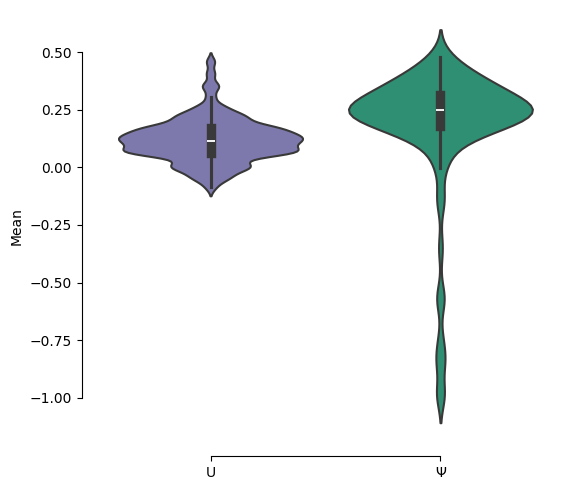

In [3]:
fff = 'mean'
data=X_mean
data=pd.DataFrame(np.array(data,dtype=float))   
print(data)
print(len(y))
data["label"]=y
data["sequence"]=['CCUAG']*len(y)
data=pd.melt(data,id_vars=["label","sequence"])
data.to_csv(f"/root/sunxh/WaveCrossMamba/data_csv/event_level_features_U_{fff}.csv")
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy import stats
data = pd.read_csv(f"/root/sunxh/WaveCrossMamba/data_csv/event_level_features_U_{fff}.csv", encoding='utf-8')
labels = data['label'].unique()

color_dict = {
    "U": (118/255, 113/255, 180/255), 
    "Ψ": (31/255, 159/255, 120/255), 
}

# 计算显著性水平
pairs = [("U", "Ψ")] 
p_values = {}
for pair in pairs:
    group1 = data[data['label'] == pair[0]]['value']
    group2 = data[data['label'] == pair[1]]['value']
    stat, p = stats.ttest_ind(group1, group2, equal_var=False)
    p_values[pair] = p

g = sns.FacetGrid(data, col="sequence", height=5, col_wrap=4, sharey=True) 
def violin_plot(x, y, **kwargs):
    ax = plt.gca()
    sns.violinplot(
        x=x, y=y, data=kwargs['data'],
        palette=color_dict,
        alpha=1.0,
        linewidth=1.5,      
        bw=0.2,             
        scale="width",      
        ax=ax
    )
    y_max = data['value'].max() * 1.2 
    step = (y_max - data['value'].min()) * 0.08 
    for i, ((group1, group2), p) in enumerate(p_values.items()):
        if p <= 0.001:
            sig = "***"
        elif p <= 0.01:
            sig = "**"
        elif p <= 0.05:
            sig = "*"
        else:
            continue
        x1, x2 = list(data['label'].unique()).index(group1), list(data['label'].unique()).index(group2)
        ax.plot([x1, x1, x2, x2], [y_max + i * step, y_max + (i + 1) * step, y_max + (i + 1) * step, y_max + i * step], lw=1.5, color='black')
        ax.text((x1 + x2) / 2, y_max + (i + 1.2) * step, sig, ha='center', va='bottom', color='black', fontsize=12)

g.map_dataframe(violin_plot, 'label', 'value')
# 美化图形
sns.despine(offset=10, trim=True) 
g.set_axis_labels("", f"Mean") 
g.set_titles("") 
g.fig.subplots_adjust(wspace=0.2, hspace=0.3) 
plt.tight_layout()
plt.savefig(f"/root/sunxh/WaveCrossMamba/result_pdf_pdf_pdf_pdf/figure_1a_event_level_features_U_{fff}.pdf", dpi=600)
plt.show()

         0
0    0.180
1    0.110
2    0.124
3    0.146
4    0.302
..     ...
195  0.136
196  0.119
197  0.009
198  0.107
199  0.141

[200 rows x 1 columns]
200


/tmp/ipykernel_11749/546442785.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_11749/546442785.py:33: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
/tmp/ipykernel_11749/546442785.py:33: FutureWarning: 

The `bw` parameter is deprecated in favor of `bw_method`/`bw_adjust`.
Setting `bw_method=0.2`, but please see docs for the new parameters
and update your code. This will become an error in seaborn v0.15.0.

  sns.violinplot(


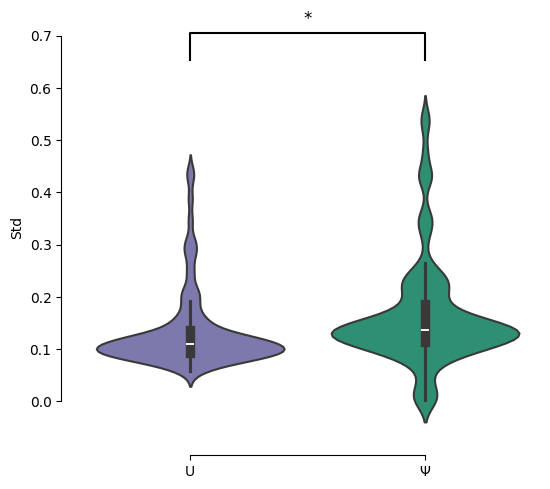

In [4]:
fff = 'std'
data=X_std
data=pd.DataFrame(np.array(data,dtype=float))   
print(data)
print(len(y))
data["label"]=y
data["sequence"]=['CCUAG']*len(y)
data=pd.melt(data,id_vars=["label","sequence"])
data.to_csv(f"/root/sunxh/WaveCrossMamba/data_csv/event_level_features_U_{fff}.csv")
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy import stats
data = pd.read_csv(f"/root/sunxh/WaveCrossMamba/data_csv/event_level_features_U_{fff}.csv", encoding='utf-8')
labels = data['label'].unique()
color_dict = {
    "U": (118/255, 113/255, 180/255), 
    "Ψ": (31/255, 159/255, 120/255), 
}

# 计算显著性水平
pairs = [("U", "Ψ")] 
p_values = {}
for pair in pairs:
    group1 = data[data['label'] == pair[0]]['value']
    group2 = data[data['label'] == pair[1]]['value']
    stat, p = stats.ttest_ind(group1, group2, equal_var=False)
    p_values[pair] = p

g = sns.FacetGrid(data, col="sequence", height=5, col_wrap=4, sharey=True) 
def violin_plot(x, y, **kwargs):
    ax = plt.gca()
    sns.violinplot(
        x=x, y=y, data=kwargs['data'],
        palette=color_dict,
        alpha=1.0,
        linewidth=1.5,      
        bw=0.2,             
        scale="width",      
        ax=ax
    )
    y_max = data['value'].max() * 1.2 
    step = (y_max - data['value'].min()) * 0.08 
    for i, ((group1, group2), p) in enumerate(p_values.items()):
        if p <= 0.001:
            sig = "***"
        elif p <= 0.01:
            sig = "**"
        elif p <= 0.05:
            sig = "*"
        else:
            continue
        x1, x2 = list(data['label'].unique()).index(group1), list(data['label'].unique()).index(group2)
        ax.plot([x1, x1, x2, x2], [y_max + i * step, y_max + (i + 1) * step, y_max + (i + 1) * step, y_max + i * step], lw=1.5, color='black')
        ax.text((x1 + x2) / 2, y_max + (i + 1.2) * step, sig, ha='center', va='bottom', color='black', fontsize=12)

g.map_dataframe(violin_plot, 'label', 'value')
# 美化图形
sns.despine(offset=10, trim=True) 
g.set_axis_labels("", f"Std") 
g.set_titles("") 
g.fig.subplots_adjust(wspace=0.2, hspace=0.3) 
plt.tight_layout()
plt.savefig(f"/root/sunxh/WaveCrossMamba/result_pdf_pdf_pdf_pdf/figure_1a_event_level_features_U_{fff}.pdf", dpi=600)
plt.show()

         0
0    0.017
1    0.168
2    0.196
3    0.117
4   -0.051
..     ...
195  0.305
196  0.135
197 -0.982
198  0.176
199  0.156

[200 rows x 1 columns]
200


/tmp/ipykernel_11749/2858138384.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_11749/2858138384.py:33: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
/tmp/ipykernel_11749/2858138384.py:33: FutureWarning: 

The `bw` parameter is deprecated in favor of `bw_method`/`bw_adjust`.
Setting `bw_method=0.2`, but please see docs for the new parameters
and update your code. This will become an error in seaborn v0.15.0.

  sns.violinplot(


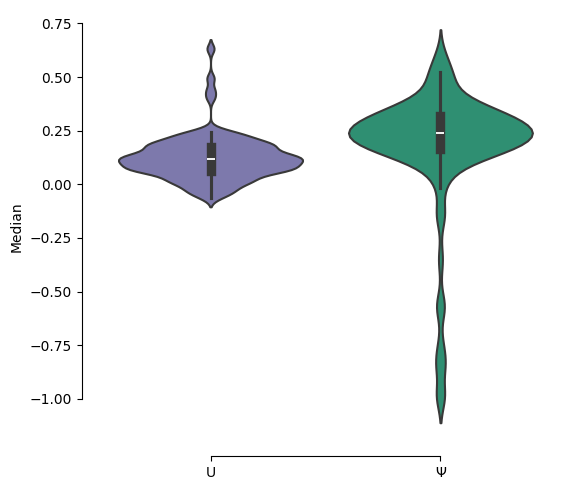

In [5]:
fff = 'median'
data=X_median
data=pd.DataFrame(np.array(data,dtype=float))   
print(data)
print(len(y))
data["label"]=y
data["sequence"]=['CCUAG']*len(y)
data=pd.melt(data,id_vars=["label","sequence"])
data.to_csv(f"/root/sunxh/WaveCrossMamba/data_csv/event_level_features_U_{fff}.csv")
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy import stats
data = pd.read_csv(f"/root/sunxh/WaveCrossMamba/data_csv/event_level_features_U_{fff}.csv", encoding='utf-8')
labels = data['label'].unique()
color_dict = {
    "U": (118/255, 113/255, 180/255), 
    "Ψ": (31/255, 159/255, 120/255), 
}

# 计算显著性水平
pairs = [("U", "Ψ")] 
p_values = {}
for pair in pairs:
    group1 = data[data['label'] == pair[0]]['value']
    group2 = data[data['label'] == pair[1]]['value']
    stat, p = stats.ttest_ind(group1, group2, equal_var=False)
    p_values[pair] = p

g = sns.FacetGrid(data, col="sequence", height=5, col_wrap=4, sharey=True) 
def violin_plot(x, y, **kwargs):
    ax = plt.gca()
    sns.violinplot(
        x=x, y=y, data=kwargs['data'],
        palette=color_dict,
        alpha=1.0,
        linewidth=1.5,      
        bw=0.2,             
        scale="width",      
        ax=ax
    )
    y_max = data['value'].max() * 1.2 
    step = (y_max - data['value'].min()) * 0.08 
    for i, ((group1, group2), p) in enumerate(p_values.items()):
        if p <= 0.001:
            sig = "***"
        elif p <= 0.01:
            sig = "**"
        elif p <= 0.05:
            sig = "*"
        else:
            continue
        x1, x2 = list(data['label'].unique()).index(group1), list(data['label'].unique()).index(group2)
        ax.plot([x1, x1, x2, x2], [y_max + i * step, y_max + (i + 1) * step, y_max + (i + 1) * step, y_max + i * step], lw=1.5, color='black')
        ax.text((x1 + x2) / 2, y_max + (i + 1.2) * step, sig, ha='center', va='bottom', color='black', fontsize=12)

g.map_dataframe(violin_plot, 'label', 'value')
# 美化图形
sns.despine(offset=10, trim=True) 
g.set_axis_labels("", f"Median") 
g.set_titles("") 
g.fig.subplots_adjust(wspace=0.2, hspace=0.3) 
plt.tight_layout()
plt.savefig(f"/root/sunxh/WaveCrossMamba/result_pdf_pdf_pdf_pdf/figure_1a_event_level_features_U_{fff}.pdf", dpi=600)
plt.show()

         0
0     12.0
1     17.0
2     48.0
3     23.0
4     32.0
..     ...
195   21.0
196  112.0
197    2.0
198    7.0
199  236.0

[200 rows x 1 columns]
200


/tmp/ipykernel_11749/1644651216.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_11749/1644651216.py:33: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
/tmp/ipykernel_11749/1644651216.py:33: FutureWarning: 

The `bw` parameter is deprecated in favor of `bw_method`/`bw_adjust`.
Setting `bw_method=0.2`, but please see docs for the new parameters
and update your code. This will become an error in seaborn v0.15.0.

  sns.violinplot(


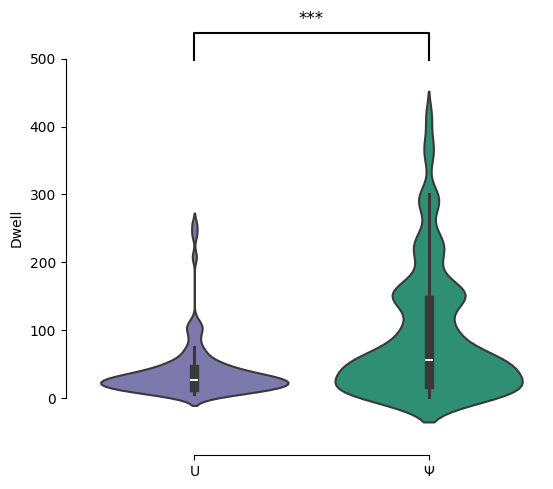

In [7]:
fff = 'dwell'
data=X_length
data=pd.DataFrame(np.array(data,dtype=float))   
print(data)
print(len(y))
data["label"]=y
data["sequence"]=['CCUAG']*len(y)
data=pd.melt(data,id_vars=["label","sequence"])
data.to_csv(f"/root/sunxh/WaveCrossMamba/data_csv/event_level_features_U_{fff}.csv")
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy import stats
data = pd.read_csv(f"/root/sunxh/WaveCrossMamba/data_csv/event_level_features_U_{fff}.csv", encoding='utf-8')
labels = data['label'].unique()
color_dict = {
    "U": (118/255, 113/255, 180/255), 
    "Ψ": (31/255, 159/255, 120/255), 
}

# 计算显著性水平
pairs = [("U", "Ψ")] 
p_values = {}
for pair in pairs:
    group1 = data[data['label'] == pair[0]]['value']
    group2 = data[data['label'] == pair[1]]['value']
    stat, p = stats.ttest_ind(group1, group2, equal_var=False)
    p_values[pair] = p

g = sns.FacetGrid(data, col="sequence", height=5, col_wrap=4, sharey=True) 
def violin_plot(x, y, **kwargs):
    ax = plt.gca()
    sns.violinplot(
        x=x, y=y, data=kwargs['data'],
        palette=color_dict,
        alpha=1.0,
        linewidth=1.5,      
        bw=0.2,             
        scale="width",      
        ax=ax
    )
    y_max = data['value'].max() * 1.2 
    step = (y_max - data['value'].min()) * 0.08 
    for i, ((group1, group2), p) in enumerate(p_values.items()):
        if p <= 0.001:
            sig = "***"
        elif p <= 0.01:
            sig = "**"
        elif p <= 0.05:
            sig = "*"
        else:
            continue
        x1, x2 = list(data['label'].unique()).index(group1), list(data['label'].unique()).index(group2)
        ax.plot([x1, x1, x2, x2], [y_max + i * step, y_max + (i + 1) * step, y_max + (i + 1) * step, y_max + i * step], lw=1.5, color='black')
        ax.text((x1 + x2) / 2, y_max + (i + 1.2) * step, sig, ha='center', va='bottom', color='black', fontsize=12)

g.map_dataframe(violin_plot, 'label', 'value')
# 美化图形
sns.despine(offset=10, trim=True) 
g.set_axis_labels("", f"Dwell") 
g.set_titles("") 
g.fig.subplots_adjust(wspace=0.2, hspace=0.3) 
plt.tight_layout()
plt.savefig(f"/root/sunxh/WaveCrossMamba/result_pdf_pdf_pdf_pdf/figure_1a_event_level_features_U_{fff}.pdf", dpi=600)
plt.show()

        0
0    15.0
1    16.0
2    16.0
3     0.0
4     3.0
..    ...
195   4.0
196   6.0
197  21.0
198  16.0
199   0.0

[200 rows x 1 columns]
200


/tmp/ipykernel_11749/2112054802.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_11749/2112054802.py:33: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
/tmp/ipykernel_11749/2112054802.py:33: FutureWarning: 

The `bw` parameter is deprecated in favor of `bw_method`/`bw_adjust`.
Setting `bw_method=0.2`, but please see docs for the new parameters
and update your code. This will become an error in seaborn v0.15.0.

  sns.violinplot(


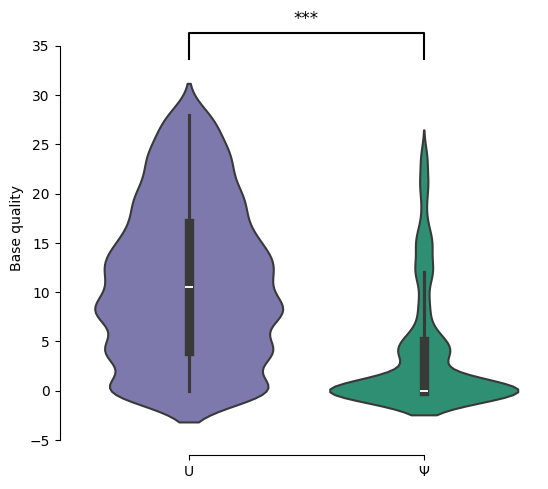

In [8]:
fff = 'base_quality'
data=X_base_quality
data=pd.DataFrame(np.array(data,dtype=float))   
print(data)
print(len(y))
data["label"]=y
data["sequence"]=['CCUAG']*len(y)
data=pd.melt(data,id_vars=["label","sequence"])
data.to_csv(f"/root/sunxh/WaveCrossMamba/data_csv/event_level_features_U_{fff}.csv")
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy import stats
data = pd.read_csv(f"/root/sunxh/WaveCrossMamba/data_csv/event_level_features_U_{fff}.csv", encoding='utf-8')
labels = data['label'].unique()
color_dict = {
    "U": (118/255, 113/255, 180/255), 
    "Ψ": (31/255, 159/255, 120/255), 
}

# 计算显著性水平
pairs = [("U", "Ψ")] 
p_values = {}
for pair in pairs:
    group1 = data[data['label'] == pair[0]]['value']
    group2 = data[data['label'] == pair[1]]['value']
    stat, p = stats.ttest_ind(group1, group2, equal_var=False)
    p_values[pair] = p

g = sns.FacetGrid(data, col="sequence", height=5, col_wrap=4, sharey=True) 
def violin_plot(x, y, **kwargs):
    ax = plt.gca()
    sns.violinplot(
        x=x, y=y, data=kwargs['data'],
        palette=color_dict,
        alpha=1.0,
        linewidth=1.5,      
        bw=0.2,             
        scale="width",      
        ax=ax
    )
    y_max = data['value'].max() * 1.2 
    step = (y_max - data['value'].min()) * 0.08 
    for i, ((group1, group2), p) in enumerate(p_values.items()):
        if p <= 0.001:
            sig = "***"
        elif p <= 0.01:
            sig = "**"
        elif p <= 0.05:
            sig = "*"
        else:
            continue
        x1, x2 = list(data['label'].unique()).index(group1), list(data['label'].unique()).index(group2)
        ax.plot([x1, x1, x2, x2], [y_max + i * step, y_max + (i + 1) * step, y_max + (i + 1) * step, y_max + i * step], lw=1.5, color='black')
        ax.text((x1 + x2) / 2, y_max + (i + 1.2) * step, sig, ha='center', va='bottom', color='black', fontsize=12)

g.map_dataframe(violin_plot, 'label', 'value')
# 美化图形
sns.despine(offset=10, trim=True) 
g.set_axis_labels("", f"Base quality") 
g.set_titles("") 
g.fig.subplots_adjust(wspace=0.2, hspace=0.3) 
plt.tight_layout()
plt.savefig(f"/root/sunxh/WaveCrossMamba/result_pdf_pdf_pdf_pdf/figure_1a_event_level_features_U_{fff}.pdf", dpi=600)
plt.show()